In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

In [ ]:
with open("../params.yaml", "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

RAW_PATH = params["data"]["raw"]

df = pd.read_csv(RAW_PATH)
df_raw = df.copy()
df.head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'data.csv'

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [58]:
df.describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [59]:
df.describe(include="object")

,Gender,family_history_with_overweight,FAVC,CAEC,SMOKE,SCC,CALC,MTRANS,NObeyesdad
count,2111,2111,2111,2111,2111,2111,2111,2111,2111
unique,2,2,2,4,2,2,4,5,7
top,Male,yes,yes,Sometimes,no,no,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,1726,1866,1765,2067,2015,1401,1580,351


In [60]:
df.isnull().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [61]:
dup = df.duplicated().sum()
print(f"Duplicate rows: {dup} ({round(dup / len(df) * 100, 2)}%)")

Duplicate rows: 24 (1.14%)


In [62]:
# From https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition

metadata = [
    ["Gender", "Feature", "Categorical", "Gender", "", "", "No"],
    ["Age", "Feature", "Continuous", "Age", "", "", "No"],
    ["Height", "Feature", "Continuous", "", "", "", "No"],
    ["Weight", "Feature", "Continuous", "", "", "", "No"],
    [
        "family_history_with_overweight",
        "Feature",
        "Binary",
        "",
        "Has a family member suffered or suffers from overweight?",
        "",
        "No",
    ],
    [
        "FAVC",
        "Feature",
        "Binary",
        "",
        "Do you eat high caloric food frequently?",
        "",
        "No",
    ],
    [
        "FCVC",
        "Feature",
        "Integer",
        "",
        "Do you usually eat vegetables in your meals?",
        "",
        "No",
    ],
    [
        "NCP",
        "Feature",
        "Continuous",
        "",
        "How many main meals do you have daily?",
        "",
        "No",
    ],
    [
        "CAEC",
        "Feature",
        "Categorical",
        "",
        "Do you eat any food between meals?",
        "",
        "No",
    ],
    ["SMOKE", "Feature", "Binary", "", "Do you smoke?", "", "No"],
    [
        "CH2O",
        "Feature",
        "Continuous",
        "",
        "How much water do you drink daily?",
        "",
        "No",
    ],
    [
        "SCC",
        "Feature",
        "Binary",
        "",
        "Do you monitor the calories you eat daily?",
        "",
        "No",
    ],
    [
        "FAF",
        "Feature",
        "Continuous",
        "",
        "How often do you have physical activity?",
        "",
        "No",
    ],
    [
        "TUE",
        "Feature",
        "Integer",
        "",
        "How much time do you use technological devices such as cell phone, videogames, television, computer and others?",
        "",
        "No",
    ],
    ["CALC", "Feature", "Categorical", "", "How often do you drink alcohol?", "", "No"],
    [
        "MTRANS",
        "Feature",
        "Categorical",
        "",
        "Which transportation do you usually use?",
        "",
        "No",
    ],
    ["NObeyesdad", "Target", "Categorical", "", "Obesity level", "", "No"],
]

columns = [
    "Variable Name",
    "Role",
    "Type",
    "Demographic",
    "Description",
    "Units",
    "Missing Values",
]

metadata_df = pd.DataFrame(metadata, columns=columns)

metadata_df

,Variable Name,Role,Type,Demographic,Description,Units,Missing Values
0,Gender,Feature,Categorical,Gender,,,No
1,Age,Feature,Continuous,Age,,,No
2,Height,Feature,Continuous,,,,No
3,Weight,Feature,Continuous,,,,No
4,family_history_with_overweight,Feature,Binary,,Has a family member suffered or suffers from o...,,No
5,FAVC,Feature,Binary,,Do you eat high caloric food frequently?,,No
6,FCVC,Feature,Integer,,Do you usually eat vegetables in your meals?,,No
7,NCP,Feature,Continuous,,How many main meals do you have daily?,,No
8,CAEC,Feature,Categorical,,Do you eat any food between meals?,,No
9,SMOKE,Feature,Binary,,Do you smoke?,,No


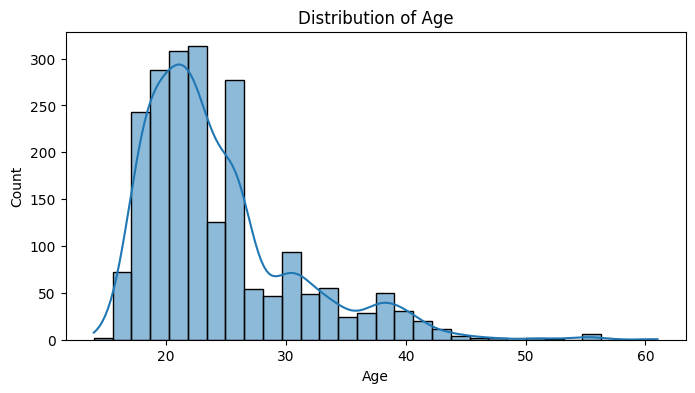

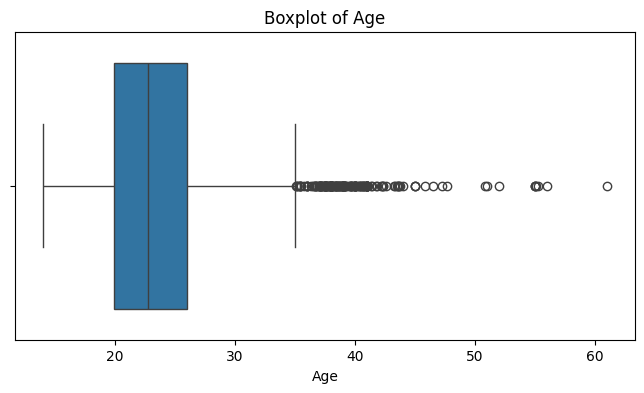

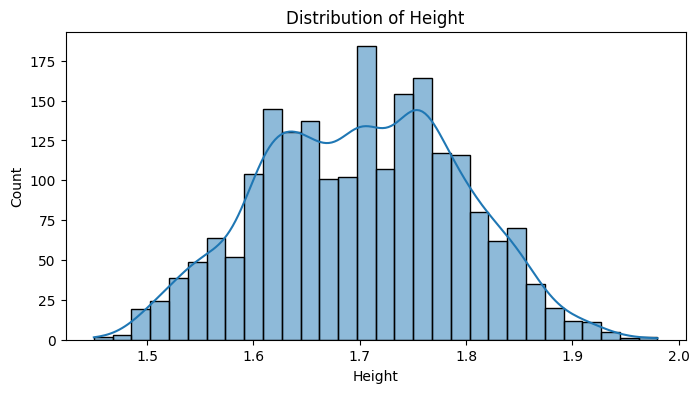

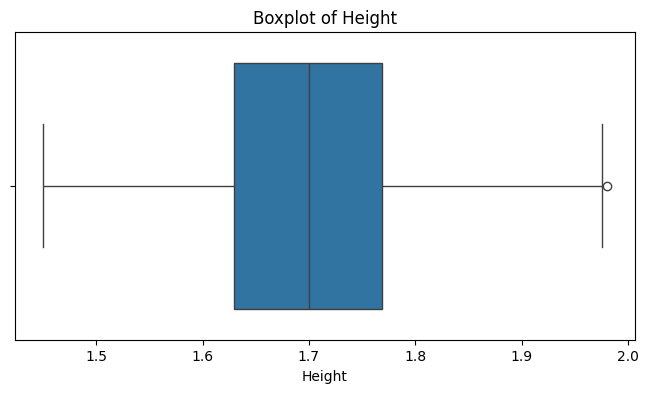

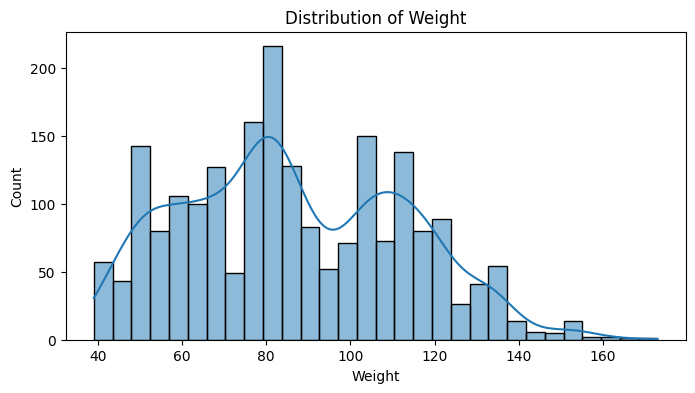

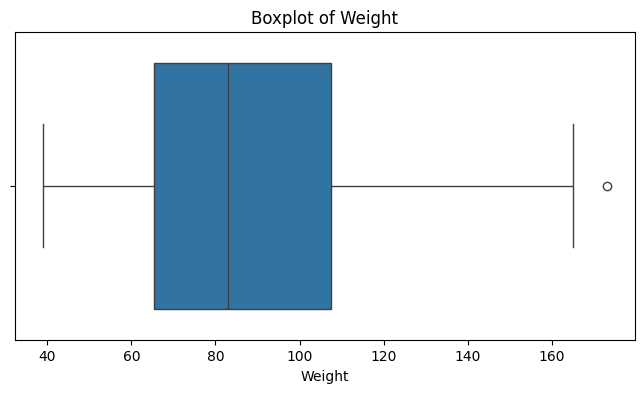

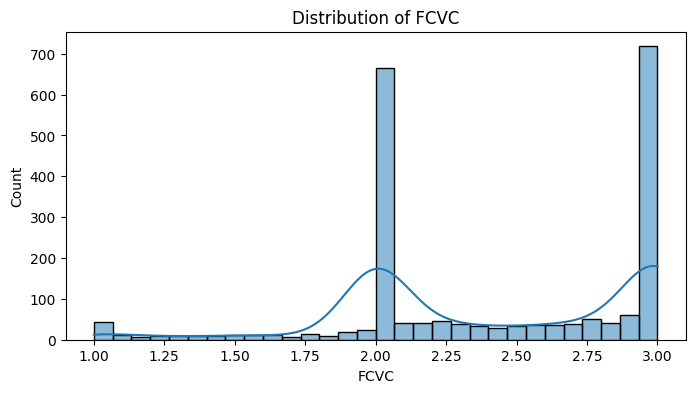

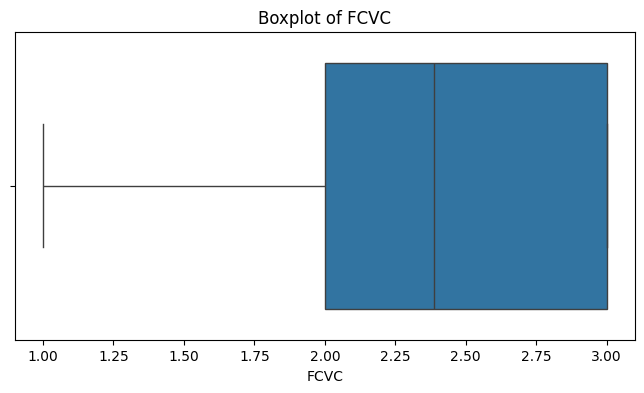

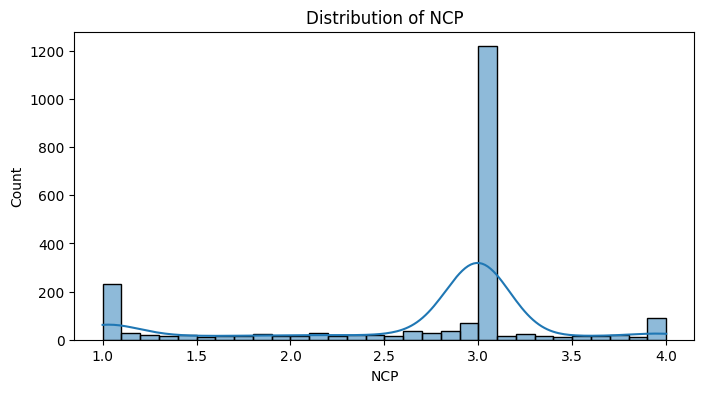

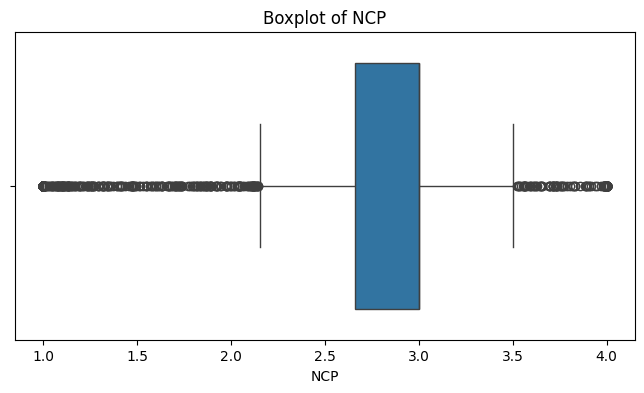

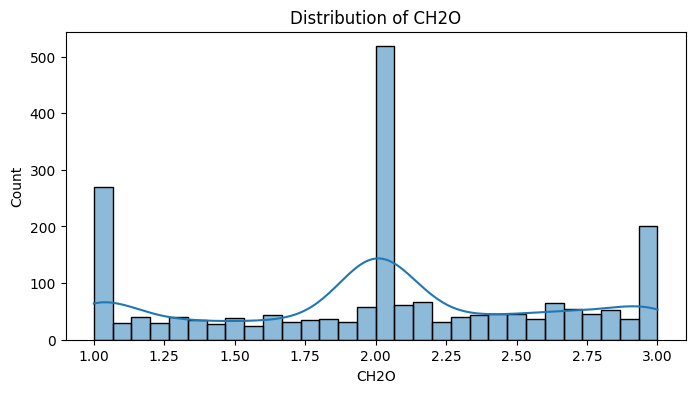

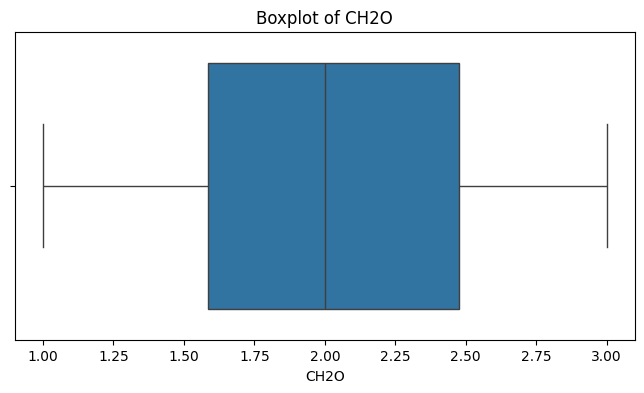

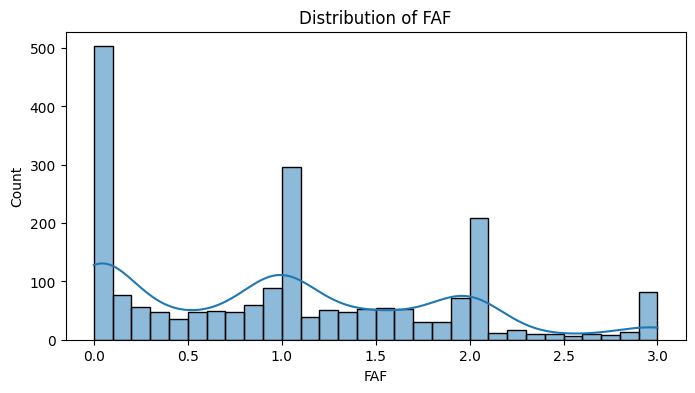

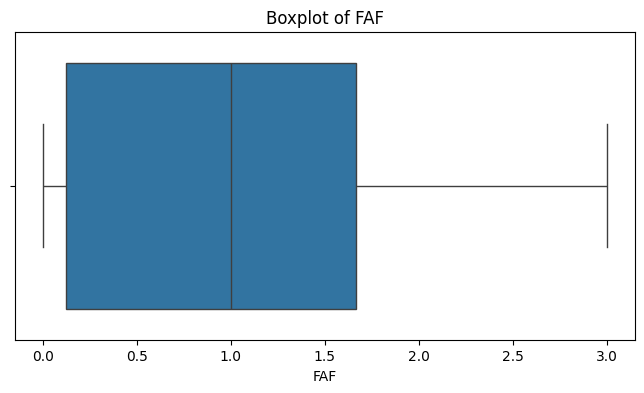

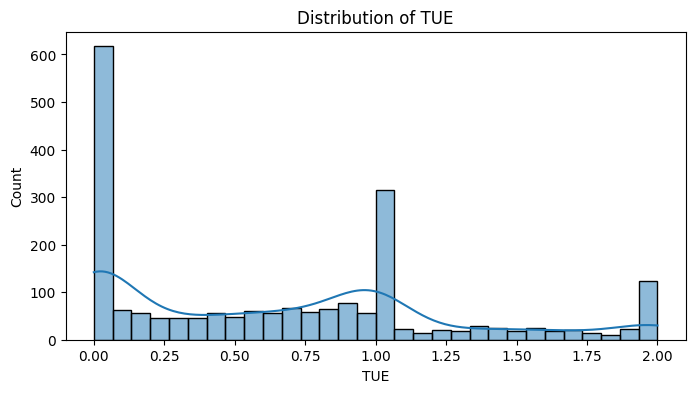

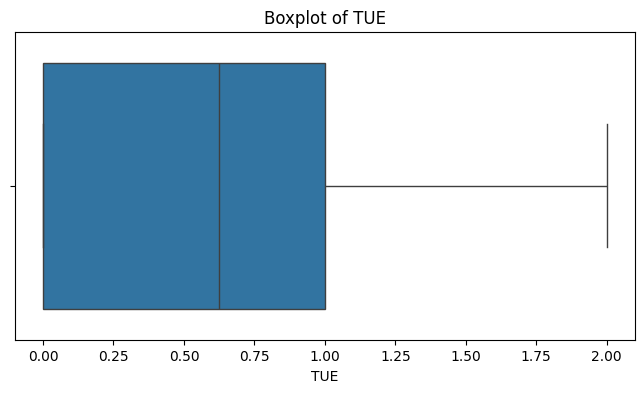

In [63]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

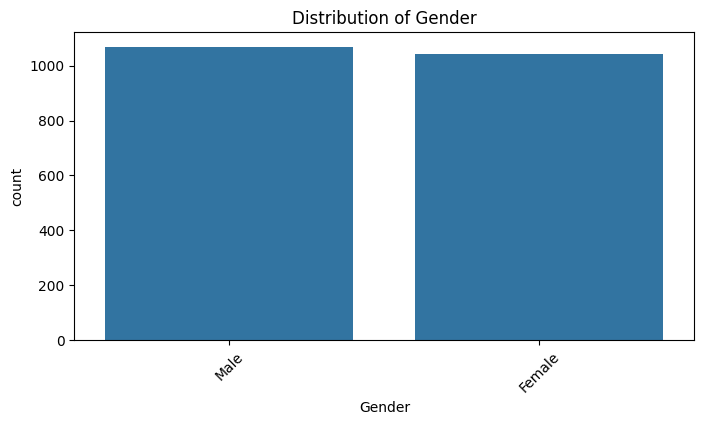

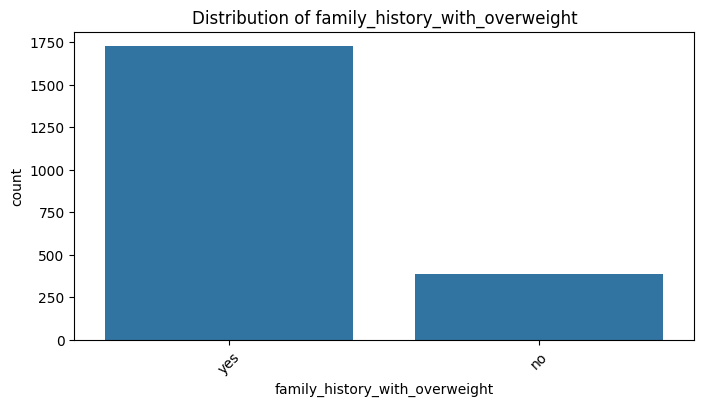

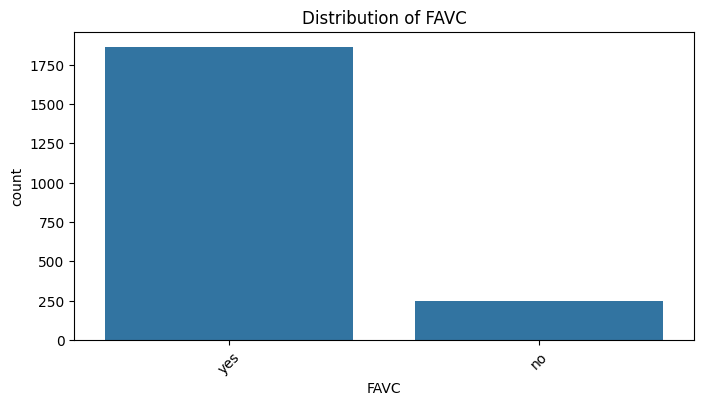

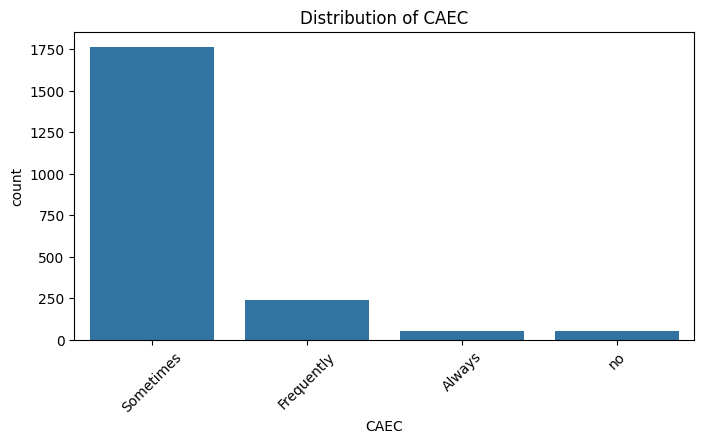

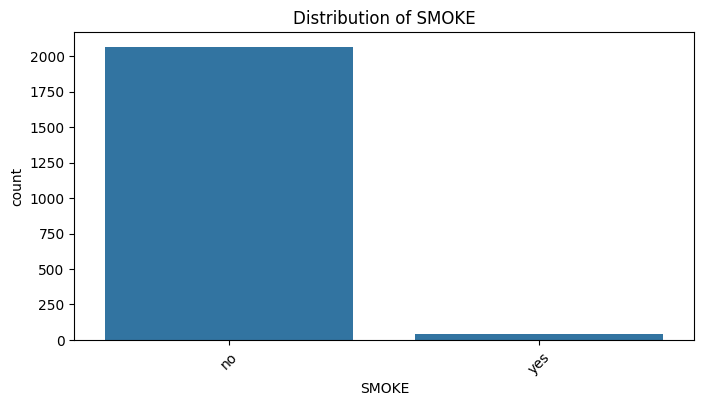

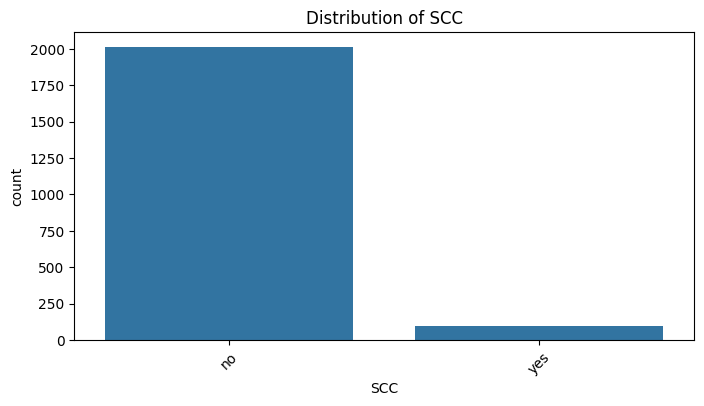

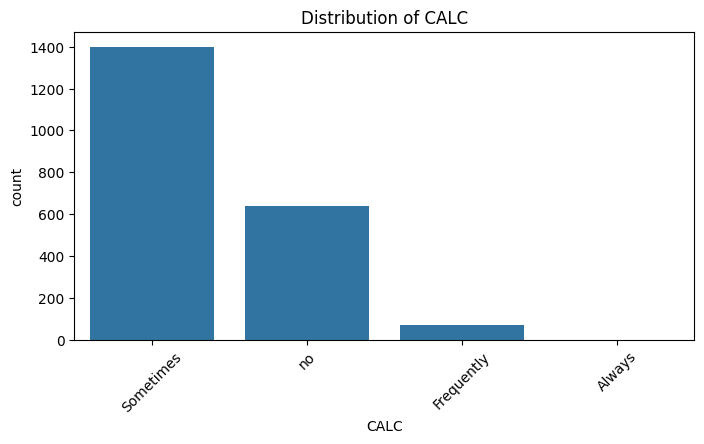

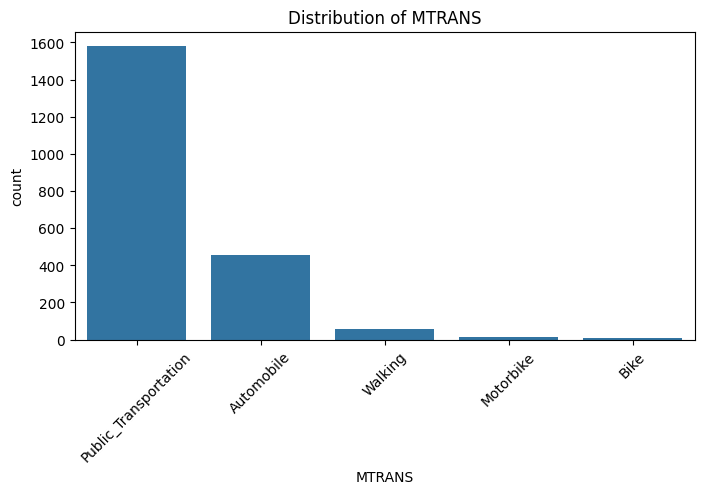

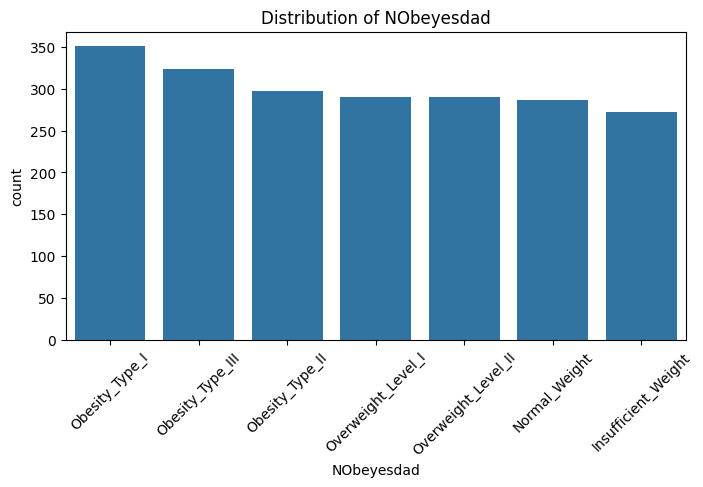

In [64]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

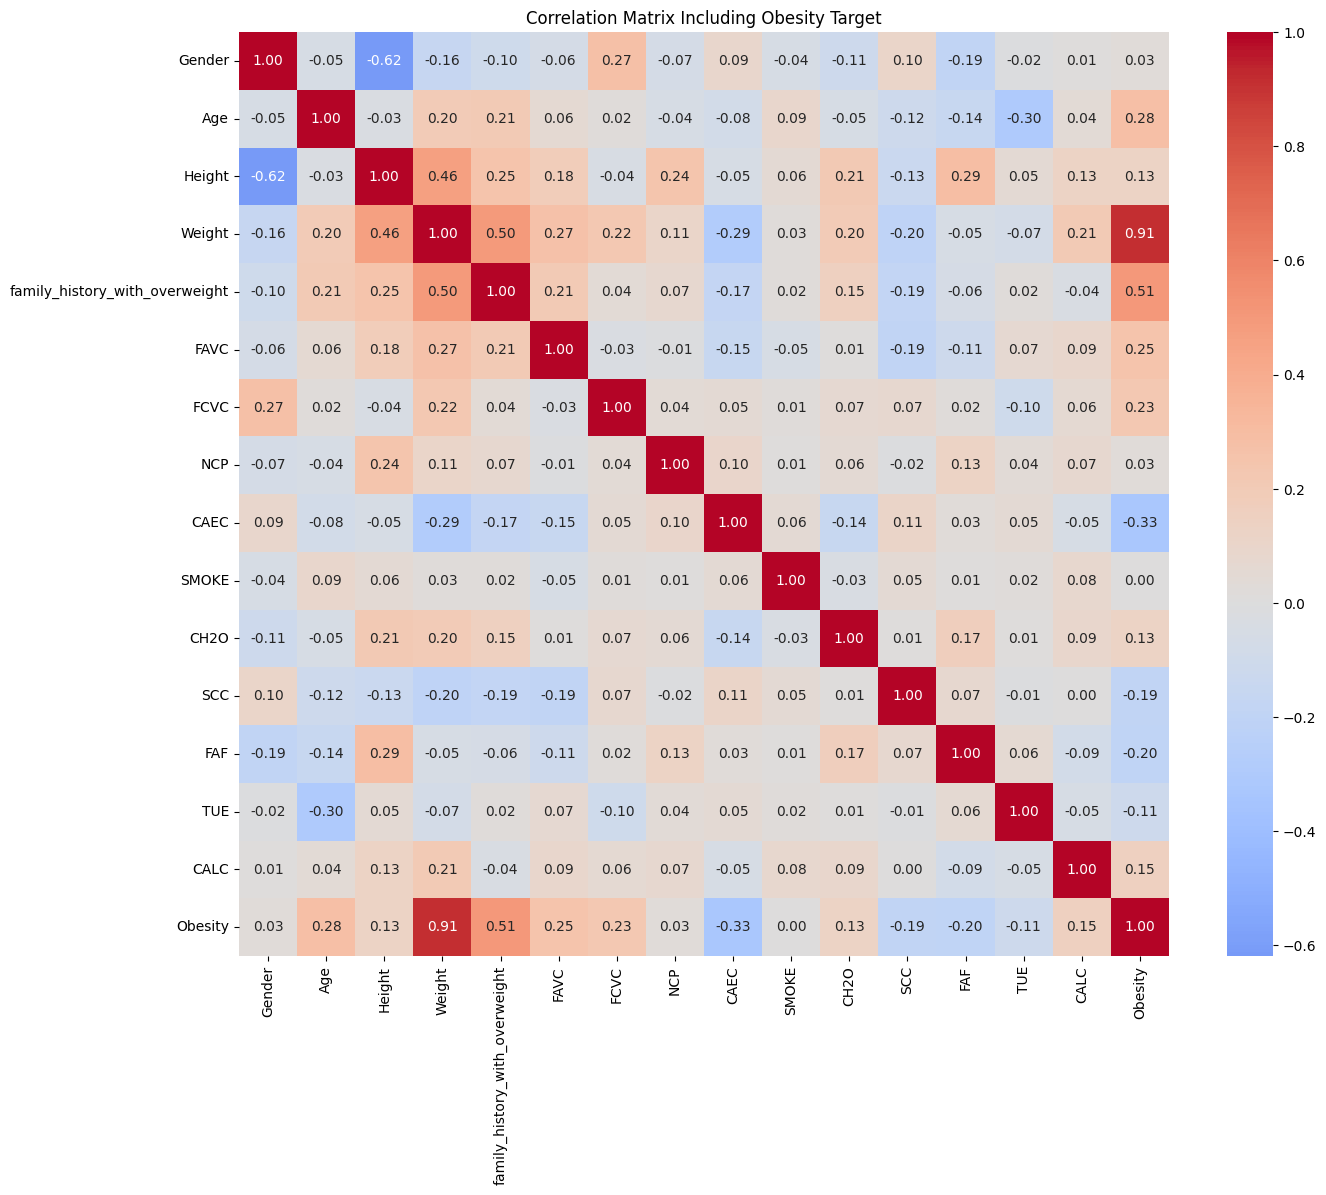

In [65]:
# Convert to numerical

caec_calc_mapping = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
df["CAEC"] = df["CAEC"].map(caec_calc_mapping)
df["CALC"] = df["CALC"].map(caec_calc_mapping)

obesity_mapping = {
    "Insufficient_Weight": 0,
    "Normal_Weight": 1,
    "Overweight_Level_I": 2,
    "Overweight_Level_II": 3,
    "Obesity_Type_I": 4,
    "Obesity_Type_II": 5,
    "Obesity_Type_III": 6,
}
df["Obesity"] = df["NObeyesdad"].map(obesity_mapping)

gender_mapping = {"Male": 0, "Female": 1}
binary_columns = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_columns:
    df[col] = df[col].map({"yes": 1, "no": 0})
df["Gender"] = df["Gender"].map(gender_mapping)

categorical_columns = ["MTRANS"]
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
plt.figure(figsize=(15, 12))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Correlation Matrix Including Obesity Target")
plt.show()

In [66]:
target_corr = corr["Obesity"].sort_values(ascending=False)
target_corr

Obesity                           1.000000
Weight                            0.913251
family_history_with_overweight    0.505148
Age                               0.282913
FAVC                              0.247793
FCVC                              0.227759
CALC                              0.151752
Height                            0.133565
CH2O                              0.133008
Gender                            0.031464
NCP                               0.026690
SMOKE                             0.003442
TUE                              -0.107991
SCC                              -0.194508
FAF                              -0.199901
CAEC                             -0.329350
Name: Obesity, dtype: float64

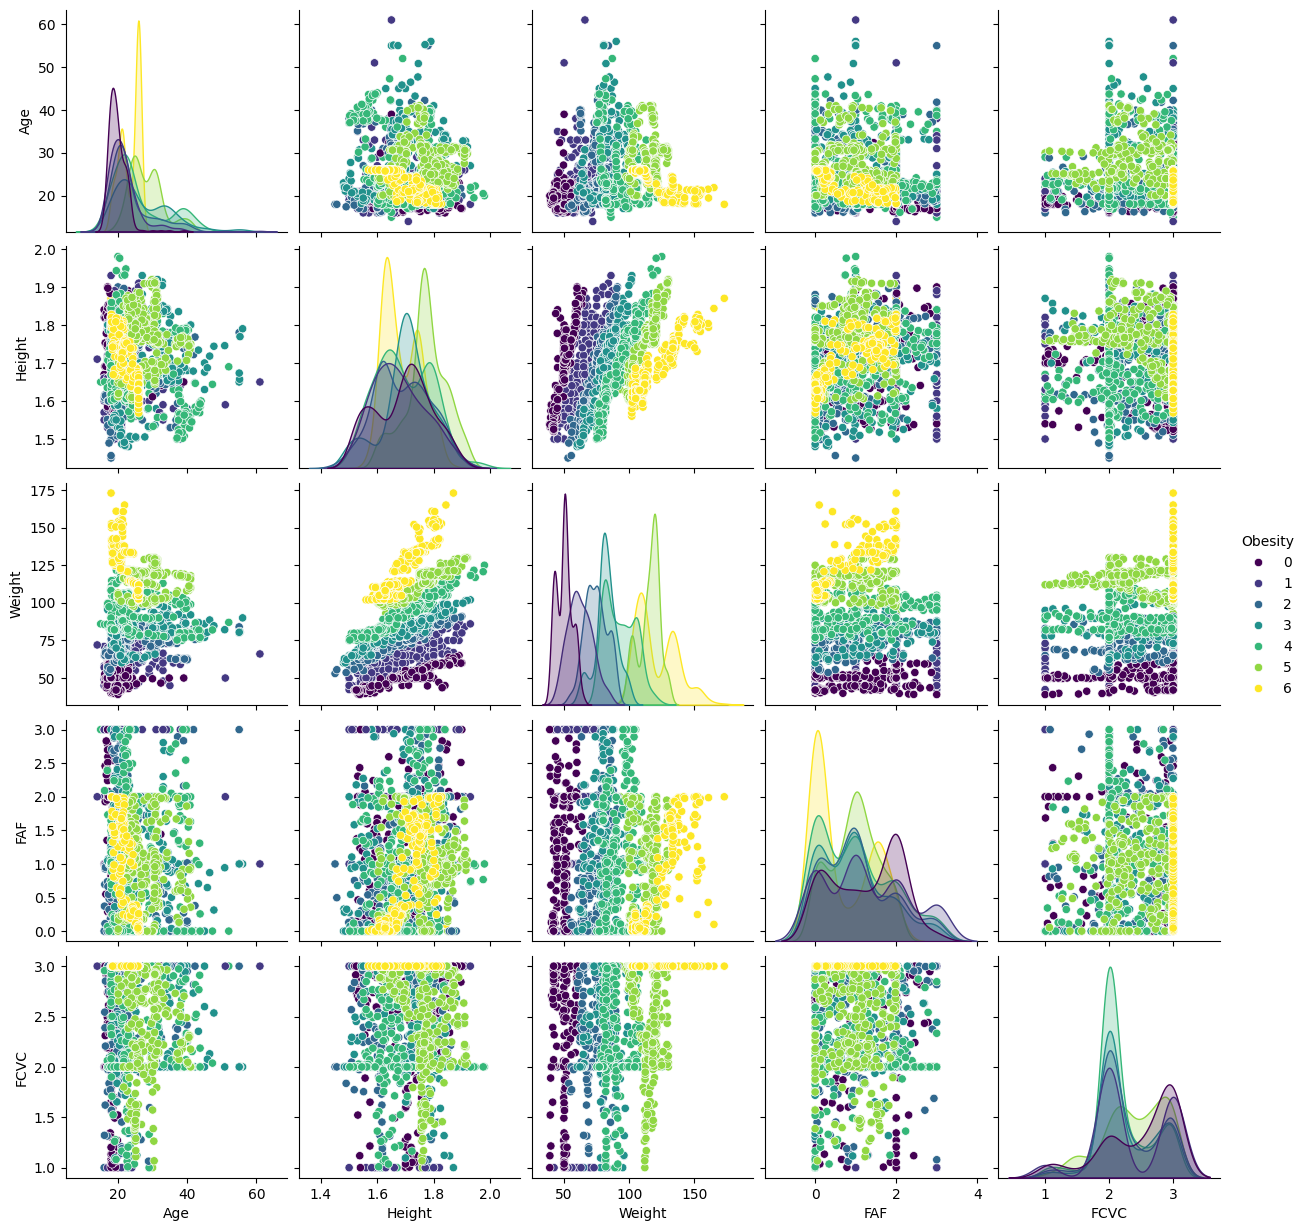

In [69]:
pairplot_features = ["Age", "Height", "Weight", "FAF", "Obesity", "FCVC"]
sns.pairplot(df[pairplot_features], hue="Obesity", palette="viridis")
plt.show()

In [ ]:
print(corr)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,Obesity
Gender,1.000000,-0.048394,-0.618466,-0.161668,-0.102512,-0.064934,0.274505,-0.067600,0.091543,-0.044698,-0.107930,0.102633,-0.189607,-0.017269,0.007616,0.031464
Age,-0.048394,1.000000,-0.025958,0.202560,0.205725,0.063902,0.016291,-0.043944,-0.083739,0.091987,-0.045304,-0.116283,-0.144938,-0.296931,0.044487,0.282913
Height,-0.618466,-0.025958,1.000000,0.463136,0.247684,0.178364,-0.038121,0.243672,-0.048818,0.055499,0.213376,-0.133753,0.294709,0.051912,0.129732,0.133565
Weight,-0.161668,0.202560,0.463136,1.000000,0.496820,0.272300,0.216125,0.107469,-0.287493,0.025746,0.200575,-0.201906,-0.051436,-0.071561,0.206677,0.913251
family_history_with_overweight,-0.102512,0.205725,0.247684,0.496820,1.000000,0.208036,0.040372,0.071370,-0.169787,0.017385,0.147437,-0.185422,-0.056673,0.022943,-0.036676,0.505148
FAVC,-0.064934,0.063902,0.178364,0.272300,0.208036,1.000000,-0.027283,-0.007000,-0.150068,-0.050660,0.009719,-0.190658,-0.107995,0.068417,0.089520,0.247793
FCVC,0.274505,0.016291,-0.038121,0.216125,0.040372,-0.027283,1.000000,0.042216,0.054670,0.014320,0.068461,0.071852,0.019939,-0.101135,0.060781,0.227759
NCP,-0.067600,-0.043944,0.243672,0.107469,0.071370,-0.007000,0.042216,1.000000,0.097801,0.007811,0.057088,-0.015624,0.129504,0.036326,0.071747,0.026690
CAEC,0.091543,-0.083739,-0.048818,-0.287493,-0.169787,-0.150068,0.054670,0.097801,1.000000,0.055282,-0.144995,0.109179,0.030110,0.048567,-0.047540,-0.329350
SMOKE,-0.044698,0.091987,0.055499,0.025746,0.017385,-0.050660,0.014320,0.007811,0.055282,1.000000,-0.031995,0.047731,0.011216,0.017613,0.082471,0.003442
